In [3]:
import os

os.listdir("data/raw")

['data-2023-01.csv',
 'Dynamische lijst 2025.xlsx',
 'OPENDATA_MAP_2017-2024.xlsx']

In [4]:
#read bike counts
import pandas as pd

bike_data = pd.read_csv("data/raw/data-2023-01.csv")

bike_data.head()

,1,IN,FIETSERS,2023-01-01 00:00:00.0,2023-01-01 00:15:00.0,0
0,1,IN,FIETSERS,2023-01-01 00:15:00.0,2023-01-01 00:30:00.0,0.0
1,1,IN,FIETSERS,2023-01-01 00:30:00.0,2023-01-01 00:45:00.0,0.0
2,1,IN,FIETSERS,2023-01-01 00:45:00.0,2023-01-01 01:00:00.0,0.0
3,1,IN,FIETSERS,2023-01-01 01:00:00.0,2023-01-01 01:15:00.0,0.0
4,1,IN,FIETSERS,2023-01-01 01:15:00.0,2023-01-01 01:30:00.0,0.0


In [5]:
bike_data = pd.read_csv(
    "data/raw/data-2023-01.csv",
    sep=";"
)

bike_data.head()

,"1,IN,FIETSERS,2023-01-01 00:00:00.0,2023-01-01 00:15:00.0,0"
0,"1,IN,FIETSERS,2023-01-01 00:15:00.0,2023-01-01..."
1,"1,IN,FIETSERS,2023-01-01 00:30:00.0,2023-01-01..."
2,"1,IN,FIETSERS,2023-01-01 00:45:00.0,2023-01-01..."
3,"1,IN,FIETSERS,2023-01-01 01:00:00.0,2023-01-01..."
4,"1,IN,FIETSERS,2023-01-01 01:15:00.0,2023-01-01..."


In [6]:
with open("data/raw/data-2023-01.csv", "r") as file:
    for i in range(5):
        print(file.readline())

1,IN,FIETSERS,2023-01-01 00:00:00.0,2023-01-01 00:15:00.0,0

1,IN,FIETSERS,2023-01-01 00:15:00.0,2023-01-01 00:30:00.0,0

1,IN,FIETSERS,2023-01-01 00:30:00.0,2023-01-01 00:45:00.0,0

1,IN,FIETSERS,2023-01-01 00:45:00.0,2023-01-01 01:00:00.0,0

1,IN,FIETSERS,2023-01-01 01:00:00.0,2023-01-01 01:15:00.0,0



In [7]:
#name headings
column_names = [
    "sensor_id",
    "direction",
    "vehicle_type",
    "start_time",
    "end_time",
    "count"
]

bike_data = pd.read_csv(
    "data/raw/data-2023-01.csv",
    header=None,
    names=column_names
)

bike_data.head()

,sensor_id,direction,vehicle_type,start_time,end_time,count
0,1,IN,FIETSERS,2023-01-01 00:00:00.0,2023-01-01 00:15:00.0,0.0
1,1,IN,FIETSERS,2023-01-01 00:15:00.0,2023-01-01 00:30:00.0,0.0
2,1,IN,FIETSERS,2023-01-01 00:30:00.0,2023-01-01 00:45:00.0,0.0
3,1,IN,FIETSERS,2023-01-01 00:45:00.0,2023-01-01 01:00:00.0,0.0
4,1,IN,FIETSERS,2023-01-01 01:00:00.0,2023-01-01 01:15:00.0,0.0


In [8]:
bike_data.info()
#17000 missing value for count, remove or fill?

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 780396 entries, 0 to 780395
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   sensor_id     780396 non-null  int64  
 1   direction     780396 non-null  object 
 2   vehicle_type  780396 non-null  object 
 3   start_time    780396 non-null  object 
 4   end_time      780396 non-null  object 
 5   count         763310 non-null  float64
dtypes: float64(1), int64(1), object(4)
memory usage: 35.7+ MB


In [9]:
bike_data['start_time']=pd.to_datetime(bike_data['start_time'])
bike_data['end_time']=pd.to_datetime(bike_data['end_time'])

In [10]:
bike_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 780396 entries, 0 to 780395
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   sensor_id     780396 non-null  int64         
 1   direction     780396 non-null  object        
 2   vehicle_type  780396 non-null  object        
 3   start_time    780396 non-null  datetime64[ns]
 4   end_time      780396 non-null  datetime64[ns]
 5   count         763310 non-null  float64       
dtypes: datetime64[ns](2), float64(1), int64(1), object(2)
memory usage: 35.7+ MB


In [11]:
#building time features
bike_data['hour']=bike_data['start_time'].dt.hour
bike_data["day_of_week"] = bike_data["start_time"].dt.day_name()
bike_data["month"] = bike_data["start_time"].dt.month
bike_data.head()

,sensor_id,direction,vehicle_type,start_time,end_time,count,hour,day_of_week,month
0,1,IN,FIETSERS,2023-01-01 00:00:00,2023-01-01 00:15:00,0.0,0,Sunday,1
1,1,IN,FIETSERS,2023-01-01 00:15:00,2023-01-01 00:30:00,0.0,0,Sunday,1
2,1,IN,FIETSERS,2023-01-01 00:30:00,2023-01-01 00:45:00,0.0,0,Sunday,1
3,1,IN,FIETSERS,2023-01-01 00:45:00,2023-01-01 01:00:00,0.0,0,Sunday,1
4,1,IN,FIETSERS,2023-01-01 01:00:00,2023-01-01 01:15:00,0.0,1,Sunday,1


In [15]:
bike_data['sensor_id'].nunique()

134

In [16]:
bike_data['count'].sum()

np.float64(1175395.0)

In [17]:
#grouping data based on hour
hourly_traffic= bike_data.groupby('hour')['count'].sum()
hourly_traffic

hour
0       6512.0
1       4847.0
2       3623.0
3       3326.0
4       6461.0
5      18405.0
6      35839.0
7     103686.0
8     126172.0
9      51536.0
10     52568.0
11     57080.0
12     76597.0
13     69495.0
14     70901.0
15     94499.0
16    121712.0
17     96945.0
18     59258.0
19     35565.0
20     25603.0
21     22927.0
22     21572.0
23     10266.0
Name: count, dtype: float64

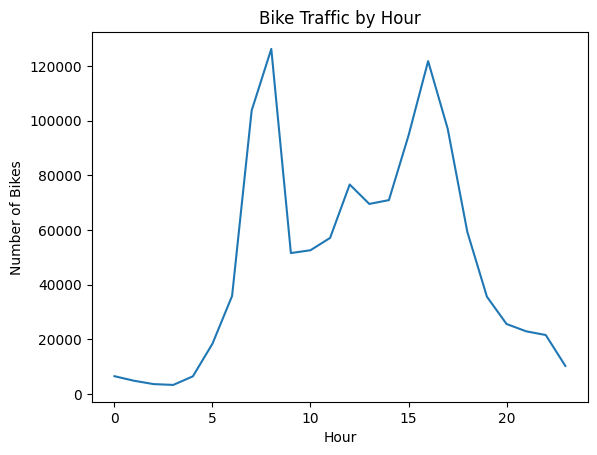

In [18]:
import matplotlib.pyplot as plt
hourly_traffic.plot()
plt.title("Bike Traffic by Hour")
plt.xlabel('Hour')
plt.ylabel('Number of Bikes')
plt.show()


In [20]:
#building hour feature
bike_data['is_peak_hour']=bike_data['hour'].isin([7,8,16,17])
bike_data[['hour', 'is_peak_hour']].head(20)

,hour,is_peak_hour
0,0,False
1,0,False
2,0,False
3,0,False
4,1,False
5,1,False
6,1,False
7,1,False
8,2,False
9,2,False


In [21]:
#building traffic features
daily_traffic=bike_data.groupby('day_of_week')['count'].sum()
daily_traffic

day_of_week
Friday       171647.0
Monday       208681.0
Saturday      95961.0
Sunday        98885.0
Thursday     158062.0
Tuesday      255995.0
Wednesday    186164.0
Name: count, dtype: float64

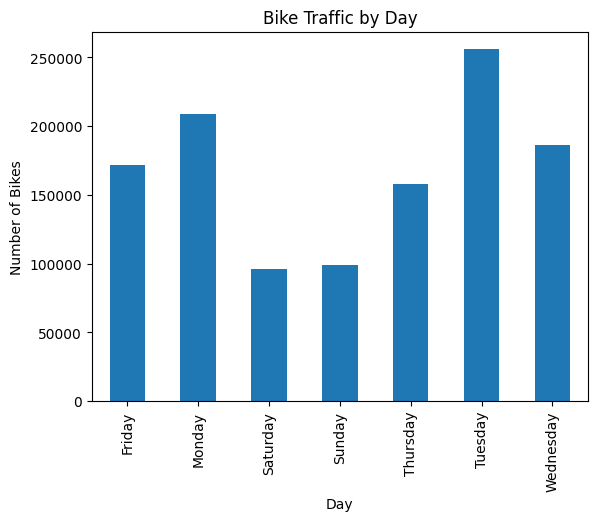

In [22]:
daily_traffic.plot(kind='bar')
plt.title("Bike Traffic by Day")
plt.xlabel('Day')
plt.ylabel('Number of Bikes')
plt.show()

In [26]:
busy_days = ["Monday", "Tuesday", "Wednesday"]
bike_data["is_busy_day"] = bike_data["day_of_week"].isin(busy_days)

In [27]:
bike_data[["day_of_week", "is_busy_day"]].drop_duplicates()

,day_of_week,is_busy_day
0,Sunday,False
96,Monday,True
192,Tuesday,True
288,Wednesday,True
384,Thursday,False
480,Friday,False
576,Saturday,False


In [29]:
#deciding for missing values
bike_data['count'].isnull().sum()

np.int64(17086)

In [31]:
bike_data=bike_data.dropna(subset=['count'])
bike_data['count'].isnull().sum()

np.int64(0)

In [33]:
#bike count time record are collected every 15 minutes,
# so i aggregate it to every 1 hour in traffic datta
hourly_sensor_traffic = bike_data.groupby(
    ["sensor_id", "hour"]
)["count"].sum().reset_index()

hourly_sensor_traffic.head()


,sensor_id,hour,count
0,1,0,45.0
1,1,1,32.0
2,1,2,23.0
3,1,3,49.0
4,1,4,56.0


In [35]:
#Total traffic by sensor
top_sensors=hourly_sensor_traffic.groupby('sensor_id'
)['count']. sum(). sort_values(ascending=False)
top_sensors.head(10)

sensor_id
107    95884.0
69     62359.0
100    32691.0
109    31040.0
125    27878.0
122    27066.0
118    23852.0
119    23480.0
52     22543.0
77     21310.0
Name: count, dtype: float64

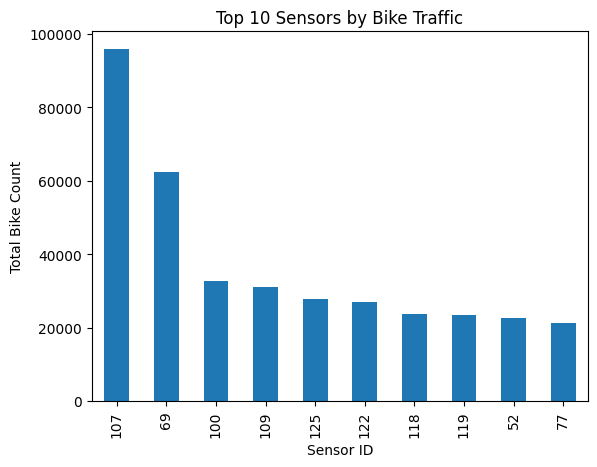

In [36]:
top_sensors.head(10).plot(kind="bar")
plt.title("Top 10 Sensors by Bike Traffic")
plt.xlabel("Sensor ID")
plt.ylabel("Total Bike Count")
plt.show()

In [42]:
import os
os.listdir("data/raw")

['data-2023-01.csv',
 'Dynamische lijst 2025.xlsx',
 'OPENDATA_MAP_2017-2024.xlsx',
 'richtingen.csv',
 'sites.csv']

In [44]:
sites=pd.read_csv('data/raw/sites.csv')
sites.head()

,1,100046096,4.456121776137429,50.91618331151478,Machelen,Vlaamse Overheid A. Wegen enVerkeer,T2110002,AWV212,Machelen.1,15,2019-08-22
0,2,100052862,4.47169,51.27512,Brasschaat 2,Vlaamse Overheid A. Wegen enVerkeer,N0010002,AWV123,Brasschaat,15,2019-08-22
1,3,100052863,4.47222,51.27503,Brasschaat 1,Vlaamse Overheid A. Wegen enVerkeer,N0010001,AWV123,Brasschaat,15,2019-08-22
2,4,100052864,5.19011,51.16023,Balen 1,Vlaamse Overheid A. Wegen enVerkeer,N0180002,AWV114,Balen,15,2019-08-22
3,5,100052865,5.19003,51.16018,Balen 2,Vlaamse Overheid A. Wegen enVerkeer,N0180002,AWV114,Balen,15,2019-08-22
4,6,100052866,3.70298,51.10894,Evergem 2,Vlaamse Overheid A. Wegen enVerkeer,N4560001,AWV413,Evergem,15,2019-08-22


In [51]:
site_columns = [
    "sensor_id",
    "site_nr",
    "longitude",
    "latitude",
    "name",
    "domain",
    "road_number",
    "district",
    "municipality",
    "interval",
    "installation_date"
]
sites = pd.read_csv(
    "data/raw/sites.csv",
    header=None,
    names=site_columns
)

sites.head()

,sensor_id,site_nr,longitude,latitude,name,domain,road_number,district,municipality,interval,installation_date
0,1,100046096,4.456122,50.916183,Machelen,Vlaamse Overheid A. Wegen enVerkeer,T2110002,AWV212,Machelen,15,2019-08-22
1,2,100052862,4.471690,51.275120,Brasschaat 2,Vlaamse Overheid A. Wegen enVerkeer,N0010002,AWV123,Brasschaat,15,2019-08-22
2,3,100052863,4.472220,51.275030,Brasschaat 1,Vlaamse Overheid A. Wegen enVerkeer,N0010001,AWV123,Brasschaat,15,2019-08-22
3,4,100052864,5.190110,51.160230,Balen 1,Vlaamse Overheid A. Wegen enVerkeer,N0180002,AWV114,Balen,15,2019-08-22
4,5,100052865,5.190030,51.160180,Balen 2,Vlaamse Overheid A. Wegen enVerkeer,N0180002,AWV114,Balen,15,2019-08-22


In [52]:
#merge two dataset
merged_data = bike_data.merge(
    sites,
    on="sensor_id",
    how="left"
)

In [53]:
merged_data.head()

,sensor_id,direction,vehicle_type,start_time,end_time,count,hour,day_of_week,month,is_peak_hour,...,site_nr,longitude,latitude,name,domain,road_number,district,municipality,interval,installation_date
0,1,IN,FIETSERS,2023-01-01 00:00:00,2023-01-01 00:15:00,0.0,0,Sunday,1,False,...,100046096,4.456122,50.916183,Machelen,Vlaamse Overheid A. Wegen enVerkeer,T2110002,AWV212,Machelen,15,2019-08-22
1,1,IN,FIETSERS,2023-01-01 00:15:00,2023-01-01 00:30:00,0.0,0,Sunday,1,False,...,100046096,4.456122,50.916183,Machelen,Vlaamse Overheid A. Wegen enVerkeer,T2110002,AWV212,Machelen,15,2019-08-22
2,1,IN,FIETSERS,2023-01-01 00:30:00,2023-01-01 00:45:00,0.0,0,Sunday,1,False,...,100046096,4.456122,50.916183,Machelen,Vlaamse Overheid A. Wegen enVerkeer,T2110002,AWV212,Machelen,15,2019-08-22
3,1,IN,FIETSERS,2023-01-01 00:45:00,2023-01-01 01:00:00,0.0,0,Sunday,1,False,...,100046096,4.456122,50.916183,Machelen,Vlaamse Overheid A. Wegen enVerkeer,T2110002,AWV212,Machelen,15,2019-08-22
4,1,IN,FIETSERS,2023-01-01 01:00:00,2023-01-01 01:15:00,0.0,1,Sunday,1,False,...,100046096,4.456122,50.916183,Machelen,Vlaamse Overheid A. Wegen enVerkeer,T2110002,AWV212,Machelen,15,2019-08-22


In [54]:
#heavy traffic cities
top_municipalities=merged_data.groupby('municipality'
)['count']. sum(). sort_values(ascending=False)
top_municipalities

municipality
Leuven                202356.0
Brugge                 78101.0
Gent                   63493.0
Dendermonde            54944.0
Kortrijk               48931.0
                        ...   
Beersel                 2009.0
Nazareth                1548.0
Halle                   1340.0
Sint-Pieters-Leeuw      1046.0
Heers                    951.0
Name: count, Length: 65, dtype: float64

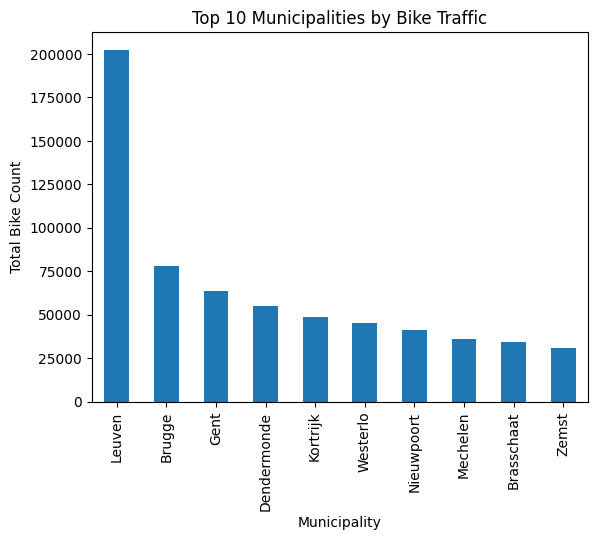

In [55]:
top_municipalities.head(10).plot(kind="bar")
plt.title("Top 10 Municipalities by Bike Traffic")
plt.xlabel("Municipality")
plt.ylabel("Total Bike Count")
plt.show()

In [65]:
#add richtingen data
directions = pd.read_csv("data/raw/richtingen.csv")
directions.head()

,1,IN,Machelen Cyclists rich. Brucargo
0,1,OUT,Machelen Cyclists richting Machelen
1,2,IN,Brasschaat 2 Fietsers rich Merksem
2,2,OUT,Brasschaat 2 Fietsers rich Brasschaat
3,3,IN,Brasschaat 1 Fietsers rich Merksem
4,3,OUT,Brasschaat 1 Fietsers rich Brasschaat


In [66]:
direction_columns = [
    "sensor_id",
    "direction",
    "direction_name"
]

directions = pd.read_csv(
    "data/raw/richtingen.csv",
    header=None,
    names=direction_columns
)

directions.head()

,sensor_id,direction,direction_name
0,1,IN,Machelen Cyclists rich. Brucargo
1,1,OUT,Machelen Cyclists richting Machelen
2,2,IN,Brasschaat 2 Fietsers rich Merksem
3,2,OUT,Brasschaat 2 Fietsers rich Brasschaat
4,3,IN,Brasschaat 1 Fietsers rich Merksem


In [70]:
#merge direction data to previuos merged data
merged_data=merged_data.merge(directions,
                              on=['sensor_id', 'direction'],
                              how="left")
merged_data.head()

,sensor_id,direction,vehicle_type,start_time,end_time,count,hour,day_of_week,month,is_peak_hour,...,latitude,name,domain,road_number,district,municipality,interval,installation_date,direction_name_x,direction_name_y
0,1,IN,FIETSERS,2023-01-01 00:00:00,2023-01-01 00:15:00,0.0,0,Sunday,1,False,...,50.916183,Machelen,Vlaamse Overheid A. Wegen enVerkeer,T2110002,AWV212,Machelen,15,2019-08-22,Machelen Cyclists rich. Brucargo,Machelen Cyclists rich. Brucargo
1,1,IN,FIETSERS,2023-01-01 00:15:00,2023-01-01 00:30:00,0.0,0,Sunday,1,False,...,50.916183,Machelen,Vlaamse Overheid A. Wegen enVerkeer,T2110002,AWV212,Machelen,15,2019-08-22,Machelen Cyclists rich. Brucargo,Machelen Cyclists rich. Brucargo
2,1,IN,FIETSERS,2023-01-01 00:30:00,2023-01-01 00:45:00,0.0,0,Sunday,1,False,...,50.916183,Machelen,Vlaamse Overheid A. Wegen enVerkeer,T2110002,AWV212,Machelen,15,2019-08-22,Machelen Cyclists rich. Brucargo,Machelen Cyclists rich. Brucargo
3,1,IN,FIETSERS,2023-01-01 00:45:00,2023-01-01 01:00:00,0.0,0,Sunday,1,False,...,50.916183,Machelen,Vlaamse Overheid A. Wegen enVerkeer,T2110002,AWV212,Machelen,15,2019-08-22,Machelen Cyclists rich. Brucargo,Machelen Cyclists rich. Brucargo
4,1,IN,FIETSERS,2023-01-01 01:00:00,2023-01-01 01:15:00,0.0,1,Sunday,1,False,...,50.916183,Machelen,Vlaamse Overheid A. Wegen enVerkeer,T2110002,AWV212,Machelen,15,2019-08-22,Machelen Cyclists rich. Brucargo,Machelen Cyclists rich. Brucargo


In [71]:
merged_data=merged_data.drop(columns=['direction_name_y'])
merged_data=merged_data.rename(columns={'direction_name_x':'direction_name'})
merged_data.head()

,sensor_id,direction,vehicle_type,start_time,end_time,count,hour,day_of_week,month,is_peak_hour,...,longitude,latitude,name,domain,road_number,district,municipality,interval,installation_date,direction_name
0,1,IN,FIETSERS,2023-01-01 00:00:00,2023-01-01 00:15:00,0.0,0,Sunday,1,False,...,4.456122,50.916183,Machelen,Vlaamse Overheid A. Wegen enVerkeer,T2110002,AWV212,Machelen,15,2019-08-22,Machelen Cyclists rich. Brucargo
1,1,IN,FIETSERS,2023-01-01 00:15:00,2023-01-01 00:30:00,0.0,0,Sunday,1,False,...,4.456122,50.916183,Machelen,Vlaamse Overheid A. Wegen enVerkeer,T2110002,AWV212,Machelen,15,2019-08-22,Machelen Cyclists rich. Brucargo
2,1,IN,FIETSERS,2023-01-01 00:30:00,2023-01-01 00:45:00,0.0,0,Sunday,1,False,...,4.456122,50.916183,Machelen,Vlaamse Overheid A. Wegen enVerkeer,T2110002,AWV212,Machelen,15,2019-08-22,Machelen Cyclists rich. Brucargo
3,1,IN,FIETSERS,2023-01-01 00:45:00,2023-01-01 01:00:00,0.0,0,Sunday,1,False,...,4.456122,50.916183,Machelen,Vlaamse Overheid A. Wegen enVerkeer,T2110002,AWV212,Machelen,15,2019-08-22,Machelen Cyclists rich. Brucargo
4,1,IN,FIETSERS,2023-01-01 01:00:00,2023-01-01 01:15:00,0.0,1,Sunday,1,False,...,4.456122,50.916183,Machelen,Vlaamse Overheid A. Wegen enVerkeer,T2110002,AWV212,Machelen,15,2019-08-22,Machelen Cyclists rich. Brucargo


In [72]:
#validate merged data
merged_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 763310 entries, 0 to 763309
Data columns (total 22 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   sensor_id          763310 non-null  int64         
 1   direction          763310 non-null  object        
 2   vehicle_type       763310 non-null  object        
 3   start_time         763310 non-null  datetime64[ns]
 4   end_time           763310 non-null  datetime64[ns]
 5   count              763310 non-null  float64       
 6   hour               763310 non-null  int32         
 7   day_of_week        763310 non-null  object        
 8   month              763310 non-null  int32         
 9   is_peak_hour       763310 non-null  bool          
 10  is_busy_day        763310 non-null  bool          
 11  site_nr            763310 non-null  int64         
 12  longitude          763310 non-null  float64       
 13  latitude           763310 non-null  float64 

In [73]:
merged_data.isnull().sum()

sensor_id            0
direction            0
vehicle_type         0
start_time           0
end_time             0
count                0
hour                 0
day_of_week          0
month                0
is_peak_hour         0
is_busy_day          0
site_nr              0
longitude            0
latitude             0
name                 0
domain               0
road_number          0
district             0
municipality         0
interval             0
installation_date    0
direction_name       0
dtype: int64

In [74]:
#explore accident data
accidents.columns

Index(['DT_YEAR_COLLISION', 'DT_MONTH_COLLISION', 'DT_TIME', 'CD_NIS',
       'TX_RGN_COLLISION_FR', 'TX_RGN_COLLISION_NL', 'TX_PROV_COLLISION_FR',
       'TX_PROV_COLLISION_NL', 'TX_MUNTY_COLLISION_FR',
       'TX_MUNTY_COLLISION_NL', 'MS_X_COORD', 'MS_Y_COORD', 'CD_CROSSWAY',
       'TX_CROSSWAY_FR', 'TX_CROSSWAY_NL', 'CD_WEATHER', 'TX_WEATHER_FR',
       'TX_WEATHER_NL', 'CD_ROAD_CONDITION', 'TX_ROAD_CONDITION_FR',
       'TX_ROAD_CONDITION_NL', 'CD_BUILD_UP_AREA', 'TX_BUILD_UP_AREA_FR',
       'TX_BUILD_UP_AREA_NL', 'CD_LIGHT_CONDITION', 'TX_LIGHT_CONDITION_FR',
       'TX_LIGHT_CONDITION_NL', 'CD_ROAD_TYPE', 'CD_ROAD_TYPE_FR',
       'CD_ROAD_TYPE_NL', 'CD_CLASS_ACCIDENTS', 'TX_CLASS_ACCIDENTS_FR',
       'TX_CLASS_ACCIDENTS_NL', 'CD_ROAD_USR_TYPE1', 'TX_ROAD_USR_TYPE1_FR',
       'TX_ROAD_USR_TYPE1_NL', 'CD_ROAD_USR_TYPE2', 'TX_ROAD_USR_TYPE2_FR',
       'TX_ROAD_USR_TYPE2_NL', 'CD_COLLISION_TYPE', 'TX_COLLISON_TYPE_FR',
       'TX_COLLISION_TYPE_NL', 'CD_OBSTACLES', 'TX_OBSTACLE

In [75]:
#keeping only flanders accidents
flanders_accidents = accidents[
    accidents["TX_RGN_COLLISION_NL"] == "Vlaams Gewest"]

flanders_accidents.head()

,DT_YEAR_COLLISION,DT_MONTH_COLLISION,DT_TIME,CD_NIS,TX_RGN_COLLISION_FR,TX_RGN_COLLISION_NL,TX_PROV_COLLISION_FR,TX_PROV_COLLISION_NL,TX_MUNTY_COLLISION_FR,TX_MUNTY_COLLISION_NL,...,TX_ROAD_USR_TYPE1_NL,CD_ROAD_USR_TYPE2,TX_ROAD_USR_TYPE2_FR,TX_ROAD_USR_TYPE2_NL,CD_COLLISION_TYPE,TX_COLLISON_TYPE_FR,TX_COLLISION_TYPE_NL,CD_OBSTACLES,TX_OBSTACLES_FR,TX_OBSTACLES_NL
1,2017,1,0,11002,Région flamande,Vlaams Gewest,Province d’Anvers,Provincie Antwerpen,Anvers,Antwerpen,...,Fiets,9,Voiture,personenauto,2,Entre 2 conducteurs: Collision frontale,Tussen 2 bestuurders: Frontale botsing,0,Pas d’obstacle,Geen hindernis
2,2017,1,1,71016,Région flamande,Vlaams Gewest,Province de Limbourg,Provincie Limburg,Genk,Genk,...,personenauto,9,Voiture,personenauto,3,Entre 2 conducteurs: Par l'arrière,Tussen 2 bestuurders: Langs achteren,0,Pas d’obstacle,Geen hindernis
4,2017,1,7,11035,Région flamande,Vlaams Gewest,Province d’Anvers,Provincie Antwerpen,Ranst,Ranst,...,personenauto,9,Voiture,personenauto,3,Entre 2 conducteurs: Par l'arrière,Tussen 2 bestuurders: Langs achteren,0,Pas d’obstacle,Geen hindernis
5,2017,1,13,11002,Région flamande,Vlaams Gewest,Province d’Anvers,Provincie Antwerpen,Anvers,Antwerpen,...,Vrachtwagen,9,Voiture,personenauto,4,Entre 2 conducteurs: Par le côté (avant/derriè...,Tss. 2 best.: langs opzij (voor-/achterkant-fl...,0,Pas d’obstacle,Geen hindernis
6,2017,1,13,11002,Région flamande,Vlaams Gewest,Province d’Anvers,Provincie Antwerpen,Anvers,Antwerpen,...,personenauto,9,Voiture,personenauto,3,Entre 2 conducteurs: Par l'arrière,Tussen 2 bestuurders: Langs achteren,0,Pas d’obstacle,Geen hindernis


In [76]:
flanders_accidents.shape

(178348, 45)

In [77]:
#keeping only bike accidents
bike_accidents = flanders_accidents[
    (flanders_accidents["TX_ROAD_USR_TYPE1_NL"] == "Fiets") |
    (flanders_accidents["TX_ROAD_USR_TYPE2_NL"] == "Fiets")]

bike_accidents.shape

(59683, 45)

In [ ]:
#finding the locations for accidents
#charachteristics of the coordination
bike_accidents[["MS_X_COORD", "MS_Y_COORD"]].head()

,MS_X_COORD,MS_Y_COORD
1,152268.069000,209633.121000
13,150662.902145,203118.931689
200,157232.033454,175893.359079
1221,154445.154102,207467.044142
1222,154899.366465,216114.621575


In [79]:
bike_accidents[["MS_X_COORD", "MS_Y_COORD"]].isnull().sum()

MS_X_COORD    6159
MS_Y_COORD    6159
dtype: int64

In [80]:
#remove accidents without coordination
bike_accidents_geo = bike_accidents.dropna(
    subset=["MS_X_COORD", "MS_Y_COORD"])
bike_accidents_geo.shape

(53524, 45)

In [82]:
#change the accidents coordination to geodataframe
import geopandas as gpd

bike_accidents_gdf = gpd.GeoDataFrame(
    bike_accidents_geo,
    geometry=gpd.points_from_xy(
        bike_accidents_geo["MS_X_COORD"],
        bike_accidents_geo["MS_Y_COORD"]
    ),
    crs="EPSG:31370"
)

bike_accidents_gdf.head()

,DT_YEAR_COLLISION,DT_MONTH_COLLISION,DT_TIME,CD_NIS,TX_RGN_COLLISION_FR,TX_RGN_COLLISION_NL,TX_PROV_COLLISION_FR,TX_PROV_COLLISION_NL,TX_MUNTY_COLLISION_FR,TX_MUNTY_COLLISION_NL,...,CD_ROAD_USR_TYPE2,TX_ROAD_USR_TYPE2_FR,TX_ROAD_USR_TYPE2_NL,CD_COLLISION_TYPE,TX_COLLISON_TYPE_FR,TX_COLLISION_TYPE_NL,CD_OBSTACLES,TX_OBSTACLES_FR,TX_OBSTACLES_NL,geometry
1,2017,1,0,11002,Région flamande,Vlaams Gewest,Province d’Anvers,Provincie Antwerpen,Anvers,Antwerpen,...,9,Voiture,personenauto,2,Entre 2 conducteurs: Collision frontale,Tussen 2 bestuurders: Frontale botsing,0,Pas d’obstacle,Geen hindernis,POINT (152268.069 209633.121)
13,2017,1,7,11001,Région flamande,Vlaams Gewest,Province d’Anvers,Provincie Antwerpen,Aartselaar,Aartselaar,...,3,Bicyclette,Fiets,4,Entre 2 conducteurs: Par le côté (avant/derriè...,Tss. 2 best.: langs opzij (voor-/achterkant-fl...,0,Pas d’obstacle,Geen hindernis,POINT (150662.902 203118.932)
200,2017,1,7,23094,Région flamande,Vlaams Gewest,Province du Brabant flamand,Provincie Vlaams-Brabant,Zaventem,Zaventem,...,3,Bicyclette,Fiets,4,Entre 2 conducteurs: Par le côté (avant/derriè...,Tss. 2 best.: langs opzij (voor-/achterkant-fl...,0,Pas d’obstacle,Geen hindernis,POINT (157232.033 175893.359)
1221,2017,1,16,11002,Région flamande,Vlaams Gewest,Province d’Anvers,Provincie Antwerpen,Anvers,Antwerpen,...,9,Voiture,personenauto,3,Entre 2 conducteurs: Par l'arrière,Tussen 2 bestuurders: Langs achteren,0,Pas d’obstacle,Geen hindernis,POINT (154445.154 207467.044)
1222,2017,1,15,11002,Région flamande,Vlaams Gewest,Province d’Anvers,Provincie Antwerpen,Anvers,Antwerpen,...,8,Piéton,Voetganger,5,Avec un piéton,Met een voetganger,0,Pas d’obstacle,Geen hindernis,POINT (154899.366 216114.622)


In [ ]:
# Traffic data has longitude and latitude coordinates in WGS84 format.
# We convert these coordinates into geometry points.
sensor_gdf = gpd.GeoDataFrame(
    merged_data,
    geometry=gpd.points_from_xy(
        merged_data["longitude"],
        merged_data["latitude"]),
    crs="EPSG:4326")
sensor_gdf.head()

,sensor_id,direction,vehicle_type,start_time,end_time,count,hour,day_of_week,month,is_peak_hour,...,latitude,name,domain,road_number,district,municipality,interval,installation_date,direction_name,geometry
0,1,IN,FIETSERS,2023-01-01 00:00:00,2023-01-01 00:15:00,0.0,0,Sunday,1,False,...,50.916183,Machelen,Vlaamse Overheid A. Wegen enVerkeer,T2110002,AWV212,Machelen,15,2019-08-22,Machelen Cyclists rich. Brucargo,POINT (4.45612 50.91618)
1,1,IN,FIETSERS,2023-01-01 00:15:00,2023-01-01 00:30:00,0.0,0,Sunday,1,False,...,50.916183,Machelen,Vlaamse Overheid A. Wegen enVerkeer,T2110002,AWV212,Machelen,15,2019-08-22,Machelen Cyclists rich. Brucargo,POINT (4.45612 50.91618)
2,1,IN,FIETSERS,2023-01-01 00:30:00,2023-01-01 00:45:00,0.0,0,Sunday,1,False,...,50.916183,Machelen,Vlaamse Overheid A. Wegen enVerkeer,T2110002,AWV212,Machelen,15,2019-08-22,Machelen Cyclists rich. Brucargo,POINT (4.45612 50.91618)
3,1,IN,FIETSERS,2023-01-01 00:45:00,2023-01-01 01:00:00,0.0,0,Sunday,1,False,...,50.916183,Machelen,Vlaamse Overheid A. Wegen enVerkeer,T2110002,AWV212,Machelen,15,2019-08-22,Machelen Cyclists rich. Brucargo,POINT (4.45612 50.91618)
4,1,IN,FIETSERS,2023-01-01 01:00:00,2023-01-01 01:15:00,0.0,1,Sunday,1,False,...,50.916183,Machelen,Vlaamse Overheid A. Wegen enVerkeer,T2110002,AWV212,Machelen,15,2019-08-22,Machelen Cyclists rich. Brucargo,POINT (4.45612 50.91618)


In [ ]:
# Convert sensor coordinates from EPSG:4326 (WGS84 latitude/longitude)
# to EPSG:31370 so they match the accident dataset coordinate system.
sensor_gdf_31370 = sensor_gdf.to_crs("EPSG:31370")
sensor_gdf_31370[["sensor_id", "geometry"]].head()


,sensor_id,geometry
0,1,POINT (156143.904 178432.685)
1,1,POINT (156143.904 178432.685)
2,1,POINT (156143.904 178432.685)
3,1,POINT (156143.904 178432.685)
4,1,POINT (156143.904 178432.685)


In [85]:
#we have records for sensor every 15 min, so we remove the duplicates
#because we only need the location
unique_sensors = sensor_gdf_31370.drop_duplicates(
    subset=["sensor_id"])
unique_sensors[["sensor_id", "municipality", "geometry"]].head()

,sensor_id,municipality,geometry
0,1,Machelen,POINT (156143.904 178432.685)
5952,2,Brasschaat,POINT (157182.957 218365.646)
11904,3,Brasschaat,POINT (157219.957 218355.684)
17856,4,Balen,POINT (207457.483 205896.897)
23808,5,Balen,POINT (207451.948 205891.273)


In [86]:
#find nearest sensor for accidents
nearest_sensors = gpd.sjoin_nearest(
    bike_accidents_gdf,
    unique_sensors,
    how="left",
    distance_col="distance_to_sensor")
nearest_sensors.head()

,DT_YEAR_COLLISION,DT_MONTH_COLLISION,DT_TIME,CD_NIS,TX_RGN_COLLISION_FR,TX_RGN_COLLISION_NL,TX_PROV_COLLISION_FR,TX_PROV_COLLISION_NL,TX_MUNTY_COLLISION_FR,TX_MUNTY_COLLISION_NL,...,latitude,name,domain,road_number,district,municipality,interval,installation_date,direction_name,distance_to_sensor
1,2017,1,0,11002,Région flamande,Vlaams Gewest,Province d’Anvers,Provincie Antwerpen,Anvers,Antwerpen,...,51.275120,Brasschaat 2,Vlaamse Overheid A. Wegen enVerkeer,N0010002,AWV123,Brasschaat,15,2019-08-22,Brasschaat 2 Fietsers rich Merksem,10020.634256
13,2017,1,7,11001,Région flamande,Vlaams Gewest,Province d’Anvers,Provincie Antwerpen,Aartselaar,Aartselaar,...,51.196471,Beveren teller 2,Vlaamse Overheid A. Wegen enVerkeer,N4850001,AWV121,Beveren,15,2022-10-06,Beveren teller 2 Fietser Haasdonk,11872.578367
200,2017,1,7,23094,Région flamande,Vlaams Gewest,Province du Brabant flamand,Provincie Vlaams-Brabant,Zaventem,Zaventem,...,50.887122,Zaventem totem,Vlaamse Overheid A. Wegen enVerkeer,R0220001,AWV212,Zaventem,15,2022-09-02,Zaventem totem Fietser Leuven,1082.916481
1221,2017,1,16,11002,Région flamande,Vlaams Gewest,Province d’Anvers,Provincie Antwerpen,Anvers,Antwerpen,...,51.275030,Brasschaat 1,Vlaamse Overheid A. Wegen enVerkeer,N0010001,AWV123,Brasschaat,15,2019-08-22,Brasschaat 1 Fietsers rich Merksem,11236.637032
1222,2017,1,15,11002,Région flamande,Vlaams Gewest,Province d’Anvers,Provincie Antwerpen,Anvers,Antwerpen,...,51.275120,Brasschaat 2,Vlaamse Overheid A. Wegen enVerkeer,N0010002,AWV123,Brasschaat,15,2019-08-22,Brasschaat 2 Fietsers rich Merksem,3206.539462


In [87]:
#save accidents with max 500m from the sensor
nearby_accidents = nearest_sensors[
    nearest_sensors["distance_to_sensor"] <= 500]
nearby_accidents.shape

(1021, 70)

In [88]:
#count accidents near eacj sensor
accidents_per_sensor = nearby_accidents.groupby(
    "sensor_id").size().reset_index(name="accident_count")
accidents_per_sensor.head()

,sensor_id,accident_count
0,2,5
1,3,6
2,5,4
3,6,15
4,7,18


In [89]:
#we have counts but its not sufficent for risk analysis
#more traffic can cause motre accidents
#so we combine accident counts with traffic volume to find actual risk

#calculate traffic for each sensor
traffic_per_sensor = merged_data.groupby(
    "sensor_id")["count"].sum().reset_index(name="total_traffic")
traffic_per_sensor.head()


,sensor_id,total_traffic
0,1,7836.0
1,2,18703.0
2,3,15550.0
3,4,2288.0
4,5,2972.0


In [91]:
#now for each sensor we have number of accidents and cycling traffic
#merge this two elemnts
risk_data= traffic_per_sensor.merge(
    accidents_per_sensor,
    on="sensor_id",
    how="left")
risk_data.head()

,sensor_id,total_traffic,accident_count
0,1,7836.0,NaN
1,2,18703.0,5.0
2,3,15550.0,6.0
3,4,2288.0,NaN
4,5,2972.0,4.0


In [92]:
#change NAN to 0
risk_data["accident_count"] = risk_data["accident_count"].fillna(0)
risk_data.head()

,sensor_id,total_traffic,accident_count
0,1,7836.0,0.0
1,2,18703.0,5.0
2,3,15550.0,6.0
3,4,2288.0,0.0
4,5,2972.0,4.0


In [93]:
#build risk rate
risk_data["risk_rate"] = (
risk_data["accident_count"] / risk_data["total_traffic"])
risk_data.head()

,sensor_id,total_traffic,accident_count,risk_rate
0,1,7836.0,0.0,0.000000
1,2,18703.0,5.0,0.000267
2,3,15550.0,6.0,0.000386
3,4,2288.0,0.0,0.000000
4,5,2972.0,4.0,0.001346


In [ ]:
#ex:sensor 5 with low traffic and high accident rate
#find most risky sensor
risk_data.sort_values(by='risk_rate',
                      ascending=False).head(10)

,sensor_id,total_traffic,accident_count,risk_rate
98,99,3261.0,22.0,0.006746
113,114,1548.0,10.0,0.006460
77,78,495.0,3.0,0.006061
13,14,1921.0,11.0,0.005726
27,28,471.0,2.0,0.004246
119,120,2124.0,8.0,0.003766
100,101,5818.0,21.0,0.003609
24,25,10117.0,35.0,0.003460
41,42,2709.0,9.0,0.003322
74,75,7309.0,24.0,0.003284


In [95]:
#Some sensors exhibit very high risk rates despite low traffic volumes

# Ranking 1: all sensors by risk rate
all_risk_ranking = risk_data.sort_values(
    by="risk_rate",
    ascending=False)
all_risk_ranking.head(10)

,sensor_id,total_traffic,accident_count,risk_rate
98,99,3261.0,22.0,0.006746
113,114,1548.0,10.0,0.006460
77,78,495.0,3.0,0.006061
13,14,1921.0,11.0,0.005726
27,28,471.0,2.0,0.004246
119,120,2124.0,8.0,0.003766
100,101,5818.0,21.0,0.003609
24,25,10117.0,35.0,0.003460
41,42,2709.0,9.0,0.003322
74,75,7309.0,24.0,0.003284


In [96]:
# Ranking 2: only sensors with enough traffic
reliable_risk_ranking = risk_data[
    risk_data["total_traffic"] >= 5000
].sort_values(
    by="risk_rate",
    ascending=False)
reliable_risk_ranking.head(10)

,sensor_id,total_traffic,accident_count,risk_rate
100,101,5818.0,21.0,0.003609
24,25,10117.0,35.0,0.003460
74,75,7309.0,24.0,0.003284
115,116,6405.0,20.0,0.003123
6,7,7033.0,18.0,0.002559
116,117,7913.0,20.0,0.002527
68,69,62359.0,128.0,0.002053
5,6,7600.0,15.0,0.001974
64,65,7309.0,14.0,0.001915
14,15,13655.0,26.0,0.001904


In [97]:
#add city names and coordinations to risk data
risk_data_with_location = risk_data.merge(
    unique_sensors[["sensor_id", "municipality", "name", "longitude", "latitude"]],
    on="sensor_id",
    how="left")

risk_data_with_location.head()

,sensor_id,total_traffic,accident_count,risk_rate,municipality,name,longitude,latitude
0,1,7836.0,0.0,0.000000,Machelen,Machelen,4.456122,50.916183
1,2,18703.0,5.0,0.000267,Brasschaat,Brasschaat 2,4.471690,51.275120
2,3,15550.0,6.0,0.000386,Brasschaat,Brasschaat 1,4.472220,51.275030
3,4,2288.0,0.0,0.000000,Balen,Balen 1,5.190110,51.160230
4,5,2972.0,4.0,0.001346,Balen,Balen 2,5.190030,51.160180


In [98]:
#rebuild rankings with this output
all_risk_ranking = risk_data_with_location.sort_values(
    by="risk_rate",
    ascending=False)
all_risk_ranking.head(10)

,sensor_id,total_traffic,accident_count,risk_rate,municipality,name,longitude,latitude
98,99,3261.0,22.0,0.006746,Mechelen,Mechelen teller 1,4.468820,51.045640
113,114,1548.0,10.0,0.006460,Nazareth,Deinze teller 1,3.555502,50.959831
77,78,495.0,3.0,0.006061,Pepingen,Pepingen teller 1,4.165200,50.758240
13,14,1921.0,11.0,0.005726,Genk,Genk,5.489270,50.971720
27,28,471.0,2.0,0.004246,Heers,Heers,5.303140,50.754880
119,120,2124.0,8.0,0.003766,Zele,Zele teller 1,4.054774,51.060767
100,101,5818.0,21.0,0.003609,Diest,Diest teller 1,5.044810,50.977990
24,25,10117.0,35.0,0.003460,Bree,Bree,5.597669,51.136795
41,42,2709.0,9.0,0.003322,Maasmechelen,Maasmechelen teller 2,5.698100,50.970430
74,75,7309.0,24.0,0.003284,Kortrijk,Kortrijk teller 2,3.257310,50.819250


In [99]:
reliable_risk_ranking = risk_data_with_location[
    risk_data_with_location["total_traffic"] >= 5000].sort_values(
    by="risk_rate",
    ascending=False)
reliable_risk_ranking.head(10)

,sensor_id,total_traffic,accident_count,risk_rate,municipality,name,longitude,latitude
100,101,5818.0,21.0,0.003609,Diest,Diest teller 1,5.044810,50.977990
24,25,10117.0,35.0,0.003460,Bree,Bree,5.597669,51.136795
74,75,7309.0,24.0,0.003284,Kortrijk,Kortrijk teller 2,3.257310,50.819250
115,116,6405.0,20.0,0.003123,Melle,Melle teller 2,3.804060,50.998611
6,7,7033.0,18.0,0.002559,Evergem,Evergem 1,3.703170,51.108900
116,117,7913.0,20.0,0.002527,Melle,Melle teller 1,3.804060,50.998611
68,69,62359.0,128.0,0.002053,Leuven,Leuven teller 1,4.715260,50.875490
5,6,7600.0,15.0,0.001974,Evergem,Evergem 2,3.702980,51.108940
64,65,7309.0,14.0,0.001915,Nieuwpoort,Nieuwpoort teller 2,2.755110,51.134350
14,15,13655.0,26.0,0.001904,Oostende,Oostende 2,2.927430,51.213710


In [100]:
#explore dangerous points data
dangerous_points = pd.read_excel("data/raw/Dynamische lijst 2025.xlsx")
dangerous_points.head()

,ObjectID,Provincie,Gemeente,Omschrijving
0,1,Antwerpen,Lier,Gevaarlijke punt in Lier: Antwerpsesteenweg nr...
1,2,Antwerpen,Balen,"Gevaarlijke punt in Balen: Molsesteenweg, N18 ..."
2,3,Antwerpen,Ravels,"Gevaarlijke punt in Ravels: Grote Baan, Kerkst..."
3,4,Antwerpen,Kontich,"Gevaarlijke punt in Kontich: Duffelsesteenweg,..."
4,5,Antwerpen,Antwerpen,Gevaarlijke punt in Antwerpen: Brusselstraat n...


In [101]:
dangerous_points.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 286 entries, 0 to 285
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   ObjectID      286 non-null    int64 
 1   Provincie     286 non-null    object
 2   Gemeente      286 non-null    object
 3   Omschrijving  286 non-null    object
dtypes: int64(1), object(3)
memory usage: 9.1+ KB


In [102]:
dangerous_points["Gemeente"].nunique()

96

In [103]:
dangerous_points["Gemeente"].value_counts().head(10)

Gemeente
Antwerpen     81
Gent          20
Brugge         9
Kontich        6
Turnhout       5
Leuven         5
Zaventem       5
Aalst          5
Mortsel        4
Aartselaar     4
Name: count, dtype: int64

In [ ]:
#dataframe dangerous points for each city
dangerous_by_municipality = dangerous_points["Gemeente"].value_counts().reset_index()
dangerous_by_municipality.columns = ["municipality", "official_dangerous_points"]
dangerous_by_municipality.head()

,municipality,official_dangerous_points
0,Antwerpen,81
1,Gent,20
2,Brugge,9
3,Kontich,6
4,Turnhout,5


In [105]:
#summarize risk data in municipality level
municipality_risk = risk_data_with_location.groupby(
    "municipality"
).agg({"total_traffic": "sum",
    "accident_count": "sum",
    "risk_rate": "mean"}).reset_index()

municipality_risk.head()

,municipality,total_traffic,accident_count,risk_rate
0,Aalst,19917.0,7.0,0.000478
1,Aalter,13817.0,13.0,0.000941
2,Aarschot,17485.0,4.0,0.000229
3,Ardooie,4818.0,3.0,0.000610
4,As,4823.0,7.0,0.001451


In [106]:
#merge municipality risk with dangerous by municipality
municipality_comparison = municipality_risk.merge(
    dangerous_by_municipality,
    on="municipality",
    how="left")

municipality_comparison["official_dangerous_points"] = (
    municipality_comparison["official_dangerous_points"].fillna(0))

municipality_comparison.head()

,municipality,total_traffic,accident_count,risk_rate,official_dangerous_points
0,Aalst,19917.0,7.0,0.000478,5.0
1,Aalter,13817.0,13.0,0.000941,0.0
2,Aarschot,17485.0,4.0,0.000229,2.0
3,Ardooie,4818.0,3.0,0.000610,1.0
4,As,4823.0,7.0,0.001451,0.0


In [107]:
#find places whicsh are not officially dangerous
#but our data shows high risk for them

hidden_risk_municipalities = municipality_comparison[
    municipality_comparison["official_dangerous_points"] == 0
].sort_values(
    by="risk_rate",
    ascending=False)

hidden_risk_municipalities.head(10)

,municipality,total_traffic,accident_count,risk_rate,official_dangerous_points
47,Nazareth,1548.0,10.0,0.006460,0.0
12,Bree,10117.0,35.0,0.003460,0.0
23,Heers,951.0,3.0,0.003165,0.0
53,Pepingen,3912.0,3.0,0.003030,0.0
21,Halle,1340.0,4.0,0.002985,0.0
45,Melle,14318.0,40.0,0.002825,0.0
16,Diest,10318.0,26.0,0.002360,0.0
52,Pelt,7578.0,13.0,0.001668,0.0
9,Bilzen,4326.0,7.0,0.001618,0.0
4,As,4823.0,7.0,0.001451,0.0


In [ ]:
#this places are not officially dangerous but have high
#accidents and traffics

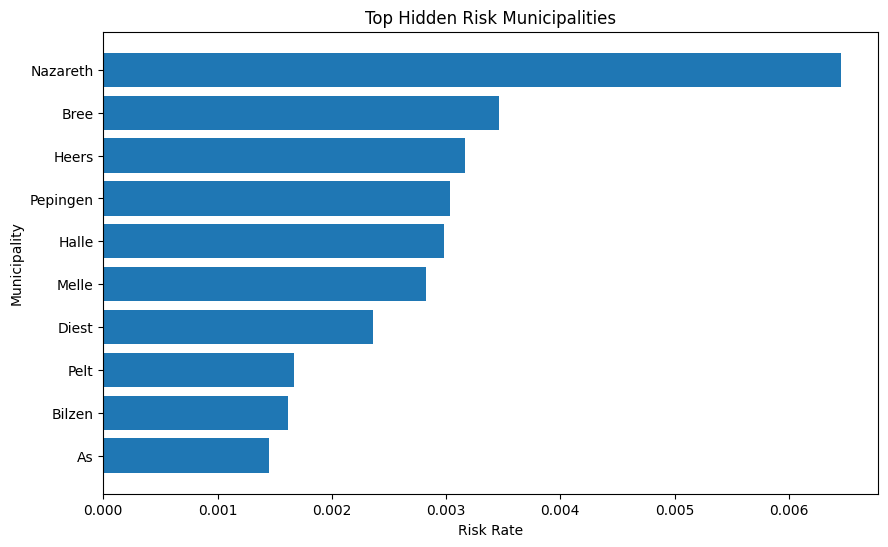

In [108]:
#top hidden risk muncipalities
import matplotlib.pyplot as plt
top_hidden = hidden_risk_municipalities.head(10)

plt.figure(figsize=(10,6))
plt.barh(
    top_hidden["municipality"],
    top_hidden["risk_rate"])

plt.xlabel("Risk Rate")
plt.ylabel("Municipality")
plt.title("Top Hidden Risk Municipalities")

plt.gca().invert_yaxis()
plt.show()

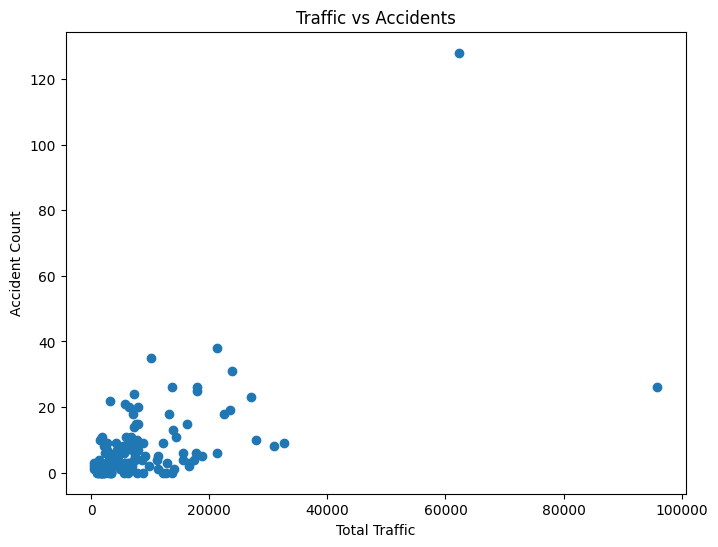

In [111]:
#tTraffic vs Accidents scatter plot
plt.figure(figsize=(8,6))

plt.scatter(
    risk_data_with_location["total_traffic"],
    risk_data_with_location["accident_count"])

plt.xlabel("Total Traffic")
plt.ylabel("Accident Count")
plt.title("Traffic vs Accidents")

plt.show()

In [112]:
#building baselines for integrating weather API

#extract date from merge data
merged_data["date"] = merged_data["start_time"].dt.date
merged_data[["start_time", "date"]].head()

,start_time,date
0,2023-01-01 00:00:00,2023-01-01
1,2023-01-01 00:15:00,2023-01-01
2,2023-01-01 00:30:00,2023-01-01
3,2023-01-01 00:45:00,2023-01-01
4,2023-01-01 01:00:00,2023-01-01


In [113]:
#extract unique municipalities
municipalities = merged_data["municipality"].unique()
len(municipalities)

65

In [114]:
#municipaliti level coordinates
municipality_coords = (
    merged_data.groupby("municipality")[["latitude", "longitude"]]
    .mean()
    .reset_index())

municipality_coords.head()

,municipality,latitude,longitude
0,Aalst,50.934557,4.015630
1,Aalter,51.105837,3.435059
2,Aarschot,50.990840,4.812590
3,Ardooie,50.967835,3.184450
4,As,51.005090,5.603890


In [115]:
#test weather API for one city
import requests

url = "https://archive-api.open-meteo.com/v1/archive"

params = {
    "latitude": 50.934557,
    "longitude": 4.015630,
    "start_date": "2023-01-01",
    "end_date": "2023-01-31",
    "daily": "temperature_2m_mean,precipitation_sum,windspeed_10m_max",
    "timezone": "Europe/Brussels"
}

response = requests.get(url, params=params)

weather_json = response.json()

weather_json.keys()

dict_keys(['latitude', 'longitude', 'generationtime_ms', 'utc_offset_seconds', 'timezone', 'timezone_abbreviation', 'elevation', 'daily_units', 'daily'])

In [116]:
#add daily weather data to dataframe
weather_df = pd.DataFrame(weather_json["daily"])
weather_df.head()

,time,temperature_2m_mean,precipitation_sum,windspeed_10m_max
0,2023-01-01,13.2,4.0,33.6
1,2023-01-02,9.9,7.0,28.2
2,2023-01-03,6.6,0.4,32.1
3,2023-01-04,11.2,4.4,33.9
4,2023-01-05,10.3,1.2,24.4


In [ ]:
#ex: define weather is for which municipality like "Aalst"
weather_df["municipality"] = "Aalst"

weather_df.head()

,time,temperature_2m_mean,precipitation_sum,windspeed_10m_max,municipality
0,2023-01-01,13.2,4.0,33.6,Aalst
1,2023-01-02,9.9,7.0,28.2,Aalst
2,2023-01-03,6.6,0.4,32.1,Aalst
3,2023-01-04,11.2,4.4,33.9,Aalst
4,2023-01-05,10.3,1.2,24.4,Aalst


In [118]:
#for all cities
all_weather = []

for index, row in municipality_coords.iterrows():
    
    params = {
        "latitude": row["latitude"],
        "longitude": row["longitude"],
        "start_date": "2023-01-01",
        "end_date": "2023-01-31",
        "daily": "temperature_2m_mean,precipitation_sum,windspeed_10m_max",
        "timezone": "Europe/Brussels"}
    
    response = requests.get(url, params=params)
    weather_json = response.json()
    
    weather_df = pd.DataFrame(weather_json["daily"])
    weather_df["municipality"] = row["municipality"]
    
    all_weather.append(weather_df)

all_weather_df = pd.concat(all_weather, ignore_index=True)
all_weather_df.head()

,time,temperature_2m_mean,precipitation_sum,windspeed_10m_max,municipality
0,2023-01-01,13.2,4.0,33.6,Aalst
1,2023-01-02,9.9,7.0,28.2,Aalst
2,2023-01-03,6.6,0.4,32.1,Aalst
3,2023-01-04,11.2,4.4,33.9,Aalst
4,2023-01-05,10.3,1.2,24.4,Aalst


In [119]:
all_weather_df.shape

(2015, 5)

In [120]:
all_weather_df["municipality"].nunique()

65

In [121]:
#change the name of column time to "date" in weather data to make merge afterward
all_weather_df["date"] = pd.to_datetime(all_weather_df["time"]).dt.date

In [122]:
#merge the data
merged_weather_data = merged_data.merge(
    all_weather_df,
    on=["municipality", "date"],
    how="left")

merged_weather_data.head()

,sensor_id,direction,vehicle_type,start_time,end_time,count,hour,day_of_week,month,is_peak_hour,...,district,municipality,interval,installation_date,direction_name,date,time,temperature_2m_mean,precipitation_sum,windspeed_10m_max
0,1,IN,FIETSERS,2023-01-01 00:00:00,2023-01-01 00:15:00,0.0,0,Sunday,1,False,...,AWV212,Machelen,15,2019-08-22,Machelen Cyclists rich. Brucargo,2023-01-01,2023-01-01,13.2,4.0,34.3
1,1,IN,FIETSERS,2023-01-01 00:15:00,2023-01-01 00:30:00,0.0,0,Sunday,1,False,...,AWV212,Machelen,15,2019-08-22,Machelen Cyclists rich. Brucargo,2023-01-01,2023-01-01,13.2,4.0,34.3
2,1,IN,FIETSERS,2023-01-01 00:30:00,2023-01-01 00:45:00,0.0,0,Sunday,1,False,...,AWV212,Machelen,15,2019-08-22,Machelen Cyclists rich. Brucargo,2023-01-01,2023-01-01,13.2,4.0,34.3
3,1,IN,FIETSERS,2023-01-01 00:45:00,2023-01-01 01:00:00,0.0,0,Sunday,1,False,...,AWV212,Machelen,15,2019-08-22,Machelen Cyclists rich. Brucargo,2023-01-01,2023-01-01,13.2,4.0,34.3
4,1,IN,FIETSERS,2023-01-01 01:00:00,2023-01-01 01:15:00,0.0,1,Sunday,1,False,...,AWV212,Machelen,15,2019-08-22,Machelen Cyclists rich. Brucargo,2023-01-01,2023-01-01,13.2,4.0,34.3


In [123]:
#missing check after merge
merged_weather_data[[
    "temperature_2m_mean",
    "precipitation_sum",
    "windspeed_10m_max"]].isnull().sum()

temperature_2m_mean    0
precipitation_sum      0
windspeed_10m_max      0
dtype: int64

In [124]:
#build features like rain or wind
merged_weather_data["is_rainy_day"] = (
    merged_weather_data["precipitation_sum"] > 0)

merged_weather_data["is_windy_day"] = (
    merged_weather_data["windspeed_10m_max"] > 30)

merged_weather_data[[
    "date", "municipality", "precipitation_sum",
    "windspeed_10m_max", "is_rainy_day", "is_windy_day"]].head()

,date,municipality,precipitation_sum,windspeed_10m_max,is_rainy_day,is_windy_day
0,2023-01-01,Machelen,4.0,34.3,True,True
1,2023-01-01,Machelen,4.0,34.3,True,True
2,2023-01-01,Machelen,4.0,34.3,True,True
3,2023-01-01,Machelen,4.0,34.3,True,True
4,2023-01-01,Machelen,4.0,34.3,True,True


In [ ]:
#check traffic (bike counts) in rainy and windy days
weather_traffic_summary = merged_weather_data.groupby(
    "is_rainy_day")["count"].mean()

weather_traffic_summary

is_rainy_day
False    1.561701
True     1.531972
Name: count, dtype: float64

In [ ]:
#build features for each sensor_id
sensor_features = merged_weather_data.groupby("sensor_id").agg({
    "count": ["sum", "mean"],
    "temperature_2m_mean": "mean",
    "precipitation_sum": "mean",
    "windspeed_10m_max": "mean",
    "is_rainy_day": "mean",
    "is_windy_day": "mean"})

sensor_features.head()

count           temperature_2m_mean precipitation_sum  \
               sum      mean                mean              mean   
sensor_id                                                            
1           7836.0  1.316532            5.270968          2.622581   
2          18703.0  3.142305            5.264516          3.612903   
3          15550.0  2.612567            5.264516          3.612903   
4           2288.0  0.384409            5.119355          3.070968   
5           2972.0  0.499328            5.119355          3.070968   

          windspeed_10m_max is_rainy_day is_windy_day  
                       mean         mean         mean  
sensor_id                                              
1                 26.661290     0.741935     0.419355  
2                 25.296774     0.709677     0.290323  
3                 25.296774     0.709677     0.290323  
4                 24.738710     0.741935     0.290323  
5                 24.738710     0.741935     0.290323

In [127]:
#clean columns name
sensor_features.columns = [
    "total_traffic",
    "avg_traffic",
    "avg_temperature",
    "avg_precipitation",
    "avg_wind_speed",
    "rainy_day_ratio",
    "windy_day_ratio"]

sensor_features = sensor_features.reset_index()
sensor_features.head()

,sensor_id,total_traffic,avg_traffic,avg_temperature,avg_precipitation,avg_wind_speed,rainy_day_ratio,windy_day_ratio
0,1,7836.0,1.316532,5.270968,2.622581,26.661290,0.741935,0.419355
1,2,18703.0,3.142305,5.264516,3.612903,25.296774,0.709677,0.290323
2,3,15550.0,2.612567,5.264516,3.612903,25.296774,0.709677,0.290323
3,4,2288.0,0.384409,5.119355,3.070968,24.738710,0.741935,0.290323
4,5,2972.0,0.499328,5.119355,3.070968,24.738710,0.741935,0.290323


In [ ]:
#merge risk rate data and accident count with sensore fatures data
sensor_features = sensor_features.merge(
    risk_data[[
        "sensor_id",
        "accident_count",
        "risk_rate"]],
    on="sensor_id",
    how="left")

sensor_features.head()


,sensor_id,total_traffic,avg_traffic,avg_temperature,avg_precipitation,avg_wind_speed,rainy_day_ratio,windy_day_ratio,accident_count,risk_rate
0,1,7836.0,1.316532,5.270968,2.622581,26.661290,0.741935,0.419355,0.0,0.000000
1,2,18703.0,3.142305,5.264516,3.612903,25.296774,0.709677,0.290323,5.0,0.000267
2,3,15550.0,2.612567,5.264516,3.612903,25.296774,0.709677,0.290323,6.0,0.000386
3,4,2288.0,0.384409,5.119355,3.070968,24.738710,0.741935,0.290323,0.0,0.000000
4,5,2972.0,0.499328,5.119355,3.070968,24.738710,0.741935,0.290323,4.0,0.001346


In [129]:
#remove missing values
sensor_features[[
    "accident_count",
    "risk_rate"]] = sensor_features[[
    "accident_count",
    "risk_rate"]].fillna(0)
sensor_features.head()

,sensor_id,total_traffic,avg_traffic,avg_temperature,avg_precipitation,avg_wind_speed,rainy_day_ratio,windy_day_ratio,accident_count,risk_rate
0,1,7836.0,1.316532,5.270968,2.622581,26.661290,0.741935,0.419355,0.0,0.000000
1,2,18703.0,3.142305,5.264516,3.612903,25.296774,0.709677,0.290323,5.0,0.000267
2,3,15550.0,2.612567,5.264516,3.612903,25.296774,0.709677,0.290323,6.0,0.000386
3,4,2288.0,0.384409,5.119355,3.070968,24.738710,0.741935,0.290323,0.0,0.000000
4,5,2972.0,0.499328,5.119355,3.070968,24.738710,0.741935,0.290323,4.0,0.001346


In [130]:
#merge location info with the data
sensor_features = sensor_features.merge(
    unique_sensors[["sensor_id", "municipality", "name", "longitude", "latitude"]],
    on="sensor_id",
    how="left")
sensor_features.head()

,sensor_id,total_traffic,avg_traffic,avg_temperature,avg_precipitation,avg_wind_speed,rainy_day_ratio,windy_day_ratio,accident_count,risk_rate,municipality,name,longitude,latitude
0,1,7836.0,1.316532,5.270968,2.622581,26.661290,0.741935,0.419355,0.0,0.000000,Machelen,Machelen,4.456122,50.916183
1,2,18703.0,3.142305,5.264516,3.612903,25.296774,0.709677,0.290323,5.0,0.000267,Brasschaat,Brasschaat 2,4.471690,51.275120
2,3,15550.0,2.612567,5.264516,3.612903,25.296774,0.709677,0.290323,6.0,0.000386,Brasschaat,Brasschaat 1,4.472220,51.275030
3,4,2288.0,0.384409,5.119355,3.070968,24.738710,0.741935,0.290323,0.0,0.000000,Balen,Balen 1,5.190110,51.160230
4,5,2972.0,0.499328,5.119355,3.070968,24.738710,0.741935,0.290323,4.0,0.001346,Balen,Balen 2,5.190030,51.160180


In [131]:
#calculate ave risk rate and define sensors with higher ave of risk
risk_threshold = sensor_features["risk_rate"].mean()

sensor_features["high_risk"] = (
    sensor_features["risk_rate"] > risk_threshold)

sensor_features[[
    "sensor_id",
    "risk_rate",
    "high_risk"]].head()

,sensor_id,risk_rate,high_risk
0,1,0.000000,False
1,2,0.000267,False
2,3,0.000386,False
3,4,0.000000,False
4,5,0.001346,True


In [132]:
#Start ML classification: x:features & y:target
#define high risk sensore by weatjer and traffic
X = sensor_features[[
    "total_traffic",
    "avg_traffic",
    "avg_temperature",
    "avg_precipitation",
    "avg_wind_speed",
    "rainy_day_ratio",
    "windy_day_ratio"]]

y = sensor_features["high_risk"]
print(X.shape)
print(y.shape)

(129, 7)
(129,)


In [133]:
#split train/test 
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42)

print(X_train.shape)
print(X_test.shape)

(103, 7)
(26, 7)


In [134]:
#build random forest model
#reasons: small dataset, feature importance, doesnt need scaling, good with nonlinear data set
#define which features are related to high risk spots

from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(
    random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [135]:
#prediction for test data

from sklearn.metrics import accuracy_score, classification_report
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.38461538461538464
              precision    recall  f1-score   support

       False       0.46      0.40      0.43        15
        True       0.31      0.36      0.33        11

    accuracy                           0.38        26
   macro avg       0.38      0.38      0.38        26
weighted avg       0.40      0.38      0.39        26



In [ ]:
#weak accuracy performance
#look for feature importance
feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
}).sort_values(
    by="importance",
    ascending=False)

feature_importance

,feature,importance
0,total_traffic,0.227087
1,avg_traffic,0.206798
4,avg_wind_speed,0.145246
3,avg_precipitation,0.132191
2,avg_temperature,0.116818
5,rainy_day_ratio,0.100874
6,windy_day_ratio,0.070986


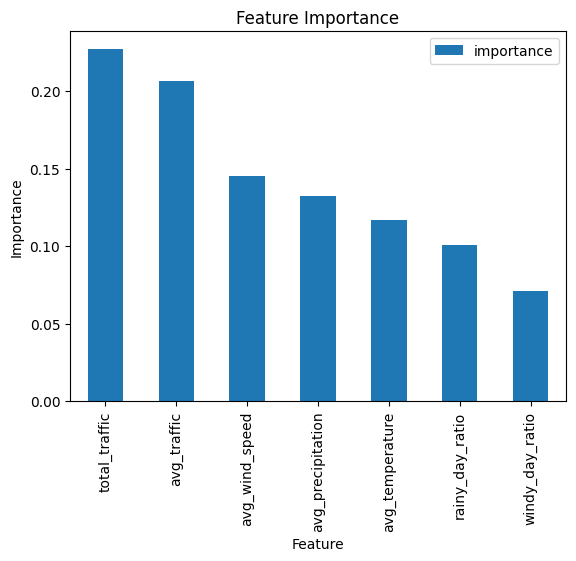

In [137]:
feature_importance.plot(
    x="feature",
    y="importance",
    kind="bar")

plt.title("Feature Importance")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.show()